# S07-demo-01 – Влияние preprocessing на качество модели (числовые признаки)

Этот ноутбук показывает, что **качество модели может меняться не только из‑за смены алгоритма, но и из‑за подготовки данных**.

Во всех основных экспериментах мы держим модель фиксированной: используем один и тот же `KNeighborsClassifier`.  
Меняться будут только шаги preprocessing:

- импутация пропусков;
- масштабирование;
- более устойчивые к выбросам варианты подготовки.

## Что вы здесь освоите

- как честно сравнивать **варианты подготовки данных** на одной и той же модели;
- почему для расстояний‑зависимых методов вроде kNN масштабирование особенно критично;
- чем отличаются `StandardScaler` и `RobustScaler` на данных с выбросами;
- как оформить эксперимент так, чтобы его можно было воспроизвести и сохранить как инженерный артефакт.


## 0. Настройки эксперимента, импорты, артефакты

Работаем в инженерном стиле:

- фиксируем `RANDOM_STATE`;
- один раз делаем `train/test split` и дальше его **не меняем**;
- все сравнения проводим в одном и том же протоколе;
- результаты сохраняем в папку `artifacts/`.

Это важно, потому что иначе легко спутать:
- реальный эффект preprocessing;
- случайную удачу разбиения;
- и просто шум эксперимента.


In [ ]:

# Базовые настройки, импорты и папка для артефактов.

from __future__ import annotations  # Позволяет использовать строковые аннотации типов в совместимом режиме

import json
import os
from pathlib import Path

# Matplotlib пытается писать кэш шрифтов: указываем локальную папку, чтобы не было ошибок прав доступа.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import joblib          # Сериализация sklearn-объектов (fitted pipeline → файл)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone                       # Создаёт «чистую» копию estimator с теми же гиперпараметрами, но без fit
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier            # Baseline: возвращает константный ответ без обучения
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

# Единый seed для воспроизводимости: влияет на np.random, train_test_split и GridSearchCV
RANDOM_STATE = 42
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)  # Создаёт папку, если её ещё нет; не бросает ошибку при повторном вызове

np.random.seed(RANDOM_STATE)

print(f"Artifacts dir: {ARTIFACTS_DIR.resolve()}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Artifacts dir: C:\Users\silaev\Desktop\s07-s08\artifacts
RANDOM_STATE = 42


In [ ]:

# Вспомогательные функции: оценка, визуализация, сохранение.

def save_json(path: Path, payload: dict) -> None:
    # ensure_ascii=False сохраняет кириллицу «как есть», без экранирования
    path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    else:
        metrics["roc_auc"] = np.nan  # Явно маркируем отсутствие вероятностей
    return metrics


def evaluate_estimator(estimator, X_train, y_train, X_test, y_test, label: str) -> dict:
    fitted = clone(estimator)  # clone гарантирует, что переданный estimator не изменится
    fitted.fit(X_train, y_train)

    y_pred = fitted.predict(X_test)

    # Пытаемся получить вероятности; для моделей без predict_proba нормируем decision_function
    y_proba = None
    if hasattr(fitted, "predict_proba"):
        y_proba = fitted.predict_proba(X_test)[:, 1]  # Вероятность положительного класса
    elif hasattr(fitted, "decision_function"):
        scores = fitted.decision_function(X_test)
        # Нормируем в [0, 1] для расчёта ROC-AUC; 1e-12 защищает от деления на ноль
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    metrics = compute_metrics(y_test, y_pred, y_proba)
    row = {"label": label, **metrics}
    return {"row": row, "model": fitted}


def plot_confusion(ax, y_true, y_pred, title: str) -> None:
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    # Числовые значения поверх каждой ячейки для удобства чтения
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")


def plot_roc(ax, y_true, y_score, title: str) -> None:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")  # Диагональ — случайный классификатор
    ax.set_title(title)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right")


## 1. Данные и контролируемое "загрязнение" признаков

Берём табличный датасет `breast_cancer` из `sklearn`:

- задача бинарной классификации;
- все признаки числовые;
- масштаб признаков различается, что уже делает задачу интересной для kNN.

Чтобы эффект preprocessing был заметнее и ближе к реальной инженерной практике, мы **после разбиения** специально добавим:

- немного пропусков;
- немного выбросов в нескольких числовых признаках.

Это учебная постановка: мы моделируем ситуацию, в которой данные уже не идеальны, и смотрим, как разные схемы подготовки помогают или мешают модели.


In [ ]:

# Загрузка данных и фиксированное train/test разбиение.

data = load_breast_cancer(as_frame=True)
X_full = data["data"].copy()    # 30 числовых признаков (геометрические параметры ядер клеток)
y_full = data["target"].copy()  # 1 = malignant (злокачественная), 0 = benign (доброкачественная)

# stratify=y_full гарантирует одинаковую долю классов в train и test
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_full,
)

print("Train shape:", X_train_clean.shape)
print("Test shape: ", X_test_clean.shape)
print("Class balance in train:", round(float(y_train.mean()), 3))
print("Class balance in test: ", round(float(y_test.mean()), 3))


Train shape: (426, 30)
Test shape:  (143, 30)
Class balance in train: 0.627
Class balance in test:  0.629


In [ ]:

# Функции для контролируемого добавления пропусков и выбросов.

def inject_missing_values(df: pd.DataFrame, frac: float, rng: np.random.Generator) -> pd.DataFrame:
    """Случайно заменяет frac * n_cells значений на NaN, не изменяя исходный датафрейм."""
    out = df.copy()
    n_rows, n_cols = out.shape
    n_cells = int(n_rows * n_cols * frac)  # Целевое число ячеек, которые станут пропусками

    # Случайные индексы строк и столбцов для «затирания»
    row_idx = rng.integers(0, n_rows, size=n_cells)
    col_idx = rng.integers(0, n_cols, size=n_cells)

    values = out.to_numpy(copy=True)
    values[row_idx, col_idx] = np.nan
    return pd.DataFrame(values, columns=out.columns, index=out.index)


def inject_outliers(
    df: pd.DataFrame,
    columns: list[str],
    frac_rows: float,
    multiplier: float,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """Умножает значения в указанных столбцах на multiplier для случайно выбранных строк."""
    out = df.copy()
    n_rows = len(out)
    n_outlier_rows = max(1, int(n_rows * frac_rows))  # Минимум одна строка с выбросом
    # replace=False гарантирует, что каждая строка-выброс выбирается не более одного раза
    chosen_rows = rng.choice(out.index.to_numpy(), size=n_outlier_rows, replace=False)

    for col in columns:
        out.loc[chosen_rows, col] = out.loc[chosen_rows, col] * multiplier

    return out


# Разные seeds для train и test: загрязнение независимо, как в реальной практике
rng_train = np.random.default_rng(RANDOM_STATE)
rng_test = np.random.default_rng(RANDOM_STATE + 1)

# Признаки с большим диапазоном значений — наиболее подходящие кандидаты для заметных выбросов
outlier_columns = ["mean area", "area error", "worst area"]

# Шаг 1: добавляем пропуски (6% всех ячеек)
X_train_corrupted = inject_missing_values(X_train_clean, frac=0.06, rng=rng_train)
X_test_corrupted = inject_missing_values(X_test_clean, frac=0.06, rng=rng_test)

# Шаг 2: добавляем выбросы поверх уже испорченных данных (x8 для 3% строк)
X_train_corrupted = inject_outliers(
    X_train_corrupted,
    columns=outlier_columns,
    frac_rows=0.03,
    multiplier=8.0,
    rng=rng_train,
)
X_test_corrupted = inject_outliers(
    X_test_corrupted,
    columns=outlier_columns,
    frac_rows=0.03,
    multiplier=8.0,
    rng=rng_test,
)

missing_train = int(X_train_corrupted.isna().sum().sum())
missing_test = int(X_test_corrupted.isna().sum().sum())

# Сводная статистика загрязнения: быстрая проверка, что данные испорчены корректно
summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(X_train_corrupted), len(X_test_corrupted)],
    "cols": [X_train_corrupted.shape[1], X_test_corrupted.shape[1]],
    "missing_cells": [missing_train, missing_test],
    "missing_share": [
        missing_train / X_train_corrupted.size,
        missing_test / X_test_corrupted.size,
    ],
})
summary


,dataset,rows,cols,missing_cells,missing_share
0,train,426,30,739,0.057825
1,test,143,30,248,0.057809


Ниже – быстрая визуальная проверка: один из признаков до и после внесения выбросов.  
Нас интересует инженерный факт: **масштаб распределения и наличие экстремальных значений могут заметно влиять на расстояния между объектами**, а значит – и на kNN.


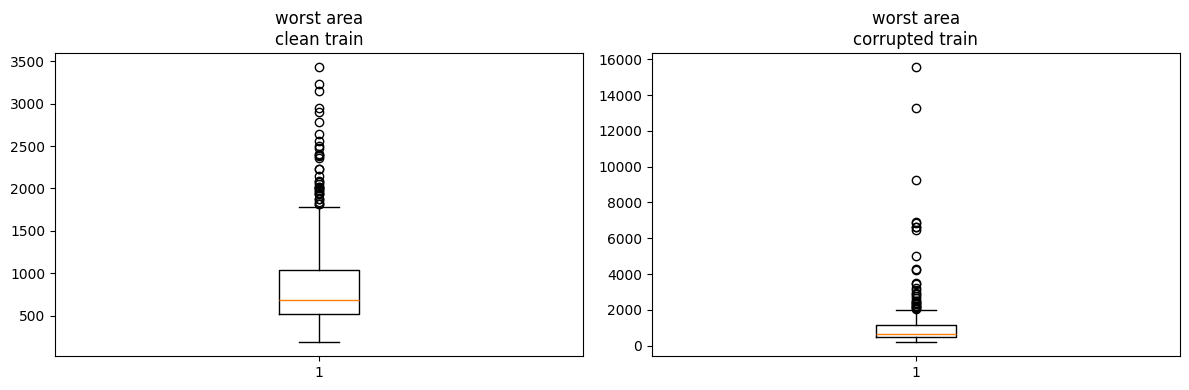

In [ ]:

# Визуальная проверка эффекта выбросов на одном из признаков.
# Ящики с усами: левый — чистые данные, правый — данные с выбросами.

feature_to_plot = "worst area"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(X_train_clean[feature_to_plot].dropna().values)
axes[0].set_title(f"{feature_to_plot}\nclean train")

axes[1].boxplot(X_train_corrupted[feature_to_plot].dropna().values)
axes[1].set_title(f"{feature_to_plot}\ncorrupted train")

plt.tight_layout()
plt.show()


## 2. Фиксируем саму модель: выбираем `k` один раз

Чтобы сравнение вариантов preprocessing было честным, мы **не будем одновременно менять и preprocessing, и модель**.

Сначала на train‑части подберём одно значение `n_neighbors` для kNN.  
Дальше во всех основных экспериментах:

- модель остаётся той же;
- `k` остаётся тем же;
- меняется только схема подготовки данных.

Это позволяет интерпретировать различия в метриках как эффект preprocessing, а не как смесь нескольких факторов.


In [ ]:

# Подбор k только на train.
# Берём умеренно лёгкий протокол, чтобы ноутбук запускался быстро и стабильно.

# StratifiedKFold сохраняет пропорции классов в каждом фолде — важно при несбалансированных данных
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# «Референсный» пайплайн используется только для выбора k; во всех дальнейших экспериментах k фиксируется
reference_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),    # Медиана устойчива к выбросам
        ("scaler", StandardScaler()),                     # Приводим признаки к одному масштабу перед kNN
        ("model", KNeighborsClassifier(weights="distance")),  # distance: ближние соседи имеют больший вес
    ]
)

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11]  # Нечётные значения исключают ничьи при голосовании
}

search = GridSearchCV(
    estimator=reference_pipe,
    param_grid=param_grid,
    scoring="roc_auc",       # ROC-AUC — хорошая метрика для несбалансированной бинарной классификации
    cv=cv,
    n_jobs=1,                # Однопоточный режим для стабильной воспроизводимости
    refit=True,              # Переобучить лучшую конфигурацию на всём train после завершения поиска
    return_train_score=False,
)

search.fit(X_train_corrupted, y_train)

best_k = search.best_params_["model__n_neighbors"]
print("best_k =", best_k)
print("best_cv_roc_auc =", round(float(search.best_score_), 4))


best_k = 11
best_cv_roc_auc = 0.9883


## 3. Варианты preprocessing для сравнения

Теперь строим несколько пайплайнов на **одной и той же** модели `KNeighborsClassifier(n_neighbors=best_k, weights="distance")`.

Сравним:

1. `DummyClassifier` – нижняя контрольная планка.  
2. `MedianImputer + kNN` – пропуски заполнили, но признаки не масштабировали.  
3. `MeanImputer + StandardScaler + kNN` – классическая базовая схема.  
4. `MedianImputer + StandardScaler + kNN` – более устойчивый вариант импутации.  
5. `MedianImputer + RobustScaler + kNN` – проверяем, помогает ли устойчивое масштабирование на данных с выбросами.  
6. `KNNImputer + StandardScaler + kNN` – более "умная", но и более тяжёлая схема импутации (работает но требует осторожности).  
7. `MedianImputer + StandardScaler + kNN` на **чистых** данных – референс, показывающий, что часть потерь связана не с самой моделью, а с ухудшением входных данных.

Важно: test‑набор у каждого эксперимента свой честный вариант:
- для corrupted‑сценариев оцениваемся на corrupted test;
- для reference‑сценария оцениваемся на clean test.

**Предупреждение:** поскольку размер тестового набора небольшой (~170 объектов), то дисперсия оценок метрик довольно высока. Небольшие различия в результатах могут быть обусловлены случайностью разбиения, а не реальным преимуществом схемы. Для более надёжных выводов потребовалась бы либо повторная кросс‑валидация с разными фолдами, либо увеличение объёма test‑набора.

In [7]:

# Описываем кандидатов так, чтобы менялся только preprocessing, а сама модель оставалась одной и той же.
# clone(knn_model) даёт каждому пайплайну независимую копию модели без состояния fit.

knn_model = KNeighborsClassifier(
    n_neighbors=best_k,   # k зафиксирован на предыдущем шаге и не меняется между вариантами
    weights="distance",
)

experiments = {
    # 1. Нижняя контрольная планка: всегда предсказывает наиболее частый класс
    "Dummy_most_frequent": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 2. Только импутация без масштабирования: ожидаем ухудшение, т.к. kNN чувствителен к масштабу
    "Median_only__kNN": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 3. Среднее + StandardScaler: классическая схема; среднее чувствительно к выбросам
    "Mean_plus_Standard__kNN": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 4. Медиана + StandardScaler: более устойчивая импутация при той же схеме масштабирования
    "Median_plus_Standard__kNN": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 5. Медиана + RobustScaler: оба трансформера устойчивы к выбросам; ожидаем лучший результат
    "Median_plus_Robust__kNN": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 6. KNNImputer: заполняет пропуски средним значением k ближайших соседей; «умнее», но медленнее
    "KNNImputer_plus_Standard__kNN": {
        "estimator": Pipeline([
            ("imputer", KNNImputer(n_neighbors=5)),
            ("scaler", StandardScaler()),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_corrupted,
        "X_test": X_test_corrupted,
    },
    # 7. Эталон на чистых данных: показывает «потолок» без загрязнения
    "Reference_clean__Median_plus_Standard__kNN": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", clone(knn_model)),
        ]),
        "X_train": X_train_clean,
        "X_test": X_test_clean,
    },
}

results = []
fitted_models = {}

# Обучаем каждый вариант и собираем метрики
for label, spec in experiments.items():
    outcome = evaluate_estimator(
        estimator=spec["estimator"],
        X_train=spec["X_train"],
        y_train=y_train,
        X_test=spec["X_test"],
        y_test=y_test,
        label=label,
    )
    results.append(outcome["row"])
    fitted_models[label] = outcome["model"]  # Сохраняем обученную модель для последующей диагностики

# Сортируем по ROC-AUC (приоритет), затем F1, затем accuracy
results_df = pd.DataFrame(results).sort_values(
    by=["roc_auc", "f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df


,label,accuracy,f1,roc_auc
0,Mean_plus_Standard__kNN,0.972028,0.978022,0.995178
1,Reference_clean__Median_plus_Standard__kNN,0.972028,0.978261,0.994549
2,KNNImputer_plus_Standard__kNN,0.965035,0.972376,0.993711
3,Median_plus_Standard__kNN,0.958042,0.967033,0.992243
4,Median_plus_Robust__kNN,0.944056,0.956522,0.992034
5,Median_only__kNN,0.909091,0.928962,0.948637
6,Dummy_most_frequent,0.629371,0.772532,0.500000


## 4. Сводка результатов

Смотрим на три метрики:

- `accuracy` – доля правильных ответов;
- `f1` – полезна, когда важен баланс precision/recall;
- `roc_auc` – удобная общая метрика ранжирования для бинарной классификации.

### Интерпретация результатов

Смысл интерпретации здесь такой:

- если **без масштабирования** kNN заметно хуже, это ожидаемо: расстояния между объектами искажаются признаками с большим масштабом;
- если кто-то выигрывает у стандартной baseline, это может быть либо реальным эффектом, либо случайной удачей (т.к. выборка небольшая);
- если разница между corrupted и clean reference заметна, значит часть потерь идёт не от "слабой модели", а от ухудшения качества входных данных.

### Контринтуитивные наблюдения

В данном эксперименте **Mean_plus_Standard__kNN на corrupted данных показывает результат, не хуже чем на clean данных**. Это может означать:
1. **Случайность выборки**: на этом конкретном разбиении train/test mean-импутация случайно восстановила выбросы так, что модель хорошо работает; на другом разбиении результат мог бы быть иной.
2. **Маленький размер теста**: тестовый набор содержит ~170 объектов, поэтому оценки имеют высокую дисперсию.
3. **Лёгкое загрязнение**: 6% пропусков и 3% выбросов могут быть недостаточны, чтобы существенно сломать model.

Вывод: эксперимент показывает **важность мониторинга влияния preprocessing**, но для более роботних выводов необходима кросс‑валидация.

In [ ]:

# Отформатированная таблица результатов и сохранение CSV.

display_df = results_df.copy()
# Округляем до 4 знаков для читаемости в таблице
for col in ["accuracy", "f1", "roc_auc"]:
    display_df[col] = display_df[col].map(lambda x: round(float(x), 4))

display_df

# Сохраняем полную (неокруглённую) таблицу для последующего анализа
results_df.to_csv(ARTIFACTS_DIR / "s07_demo_01_results.csv", index=False)


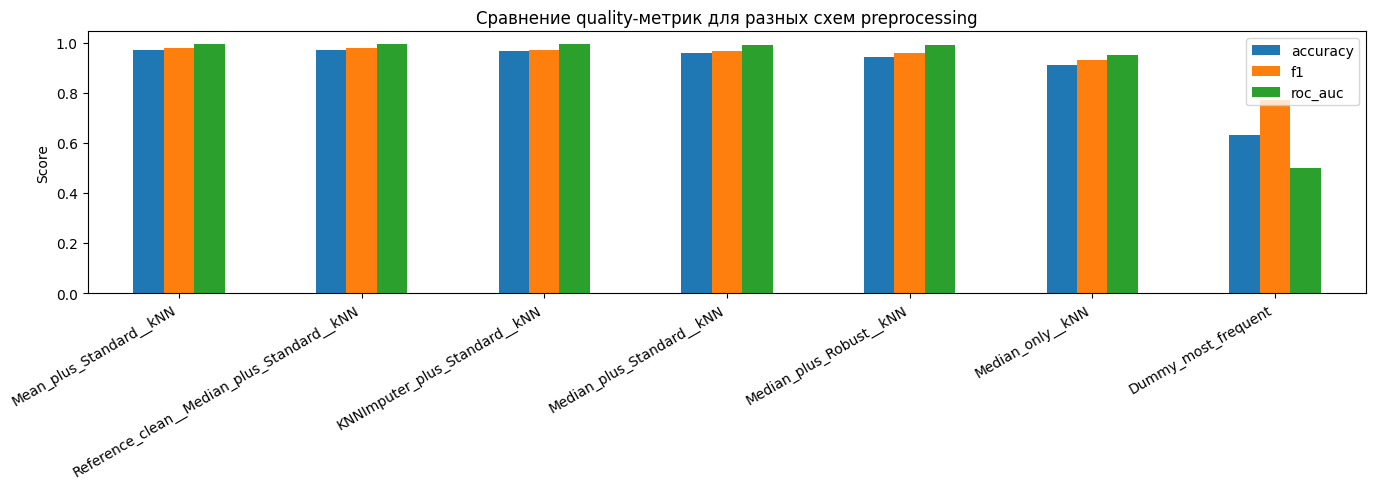

In [9]:

# Визуальное сравнение метрик по вариантам preprocessing.

# Индексируем по имени эксперимента, чтобы каждая группа столбцов соответствовала одной схеме
plot_df = results_df.set_index("label")[["accuracy", "f1", "roc_auc"]]

# Группированная гистограмма: каждая метрика отдельным цветом для сравнения схем «в лоб»
ax = plot_df.plot.bar(figsize=(14, 5))
ax.set_title("Сравнение quality-метрик для разных схем preprocessing")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")  # Поворот подписей, чтобы длинные названия не перекрывались
plt.tight_layout()
plt.show()


## 5. Лучшая и слабая схемы: быстрая диагностика

Сводная таблица полезна, но инженеру часто нужно увидеть ещё и **тип ошибок**.

Ниже сравним:
- лучшую схему preprocessing на corrupted data;
- и заведомо слабую схему без масштабирования.

Для kNN это особенно показательно: при плохой геометрии признаков ошибки часто растут сразу и по `F1`, и по `ROC-AUC`.

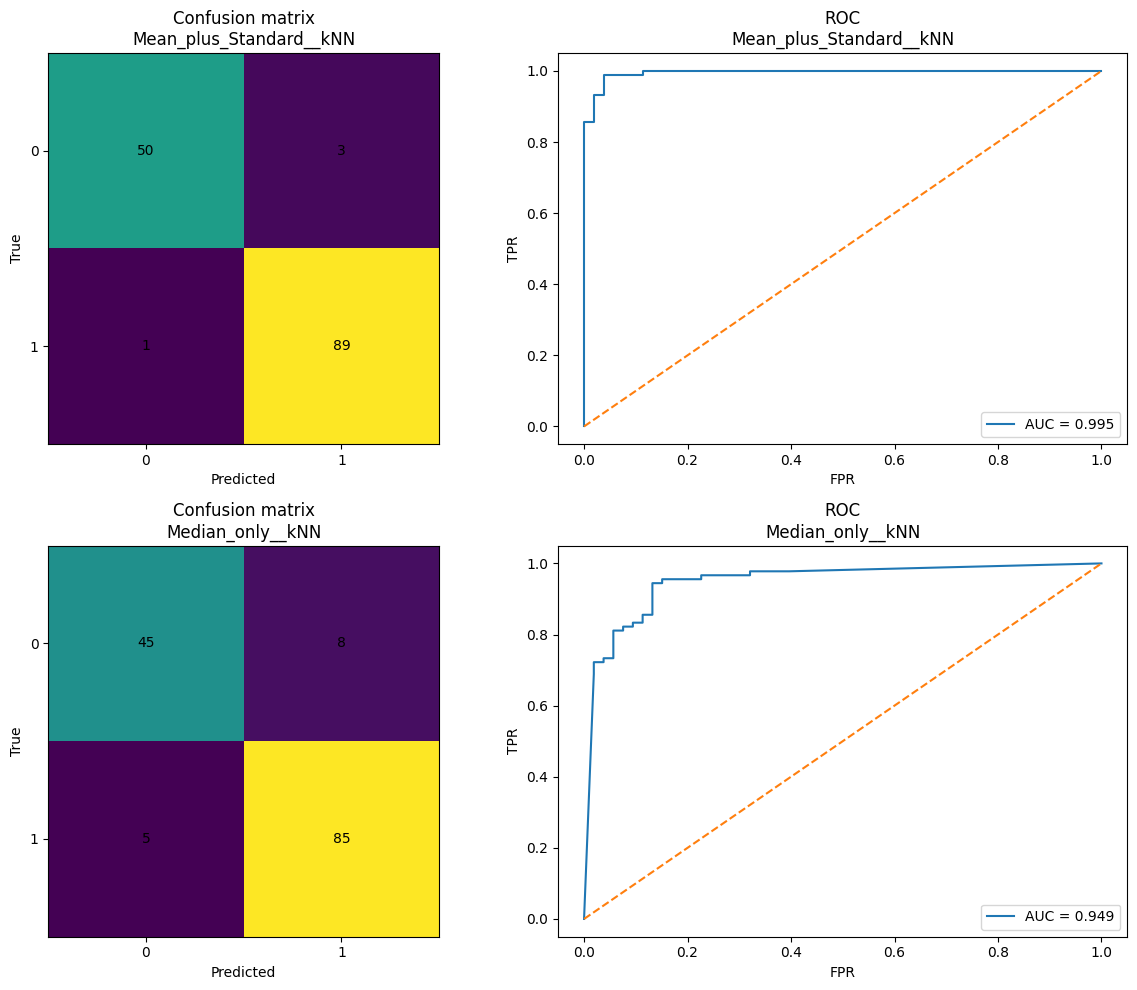

In [10]:

# Выбираем лучшую "реальную" corrupted-схему и базовую слабую схему для диагностики.

# Исключаем reference-эксперимент на чистых данных: он не конкурент для corrupted-схем
corrupted_only = results_df[~results_df["label"].str.startswith("Reference_clean")].copy()

# После сортировки по ROC-AUC первая строка — лучший corrupted-эксперимент
best_label = corrupted_only.iloc[0]["label"]
weak_label = "Median_only__kNN"  # Схема без масштабирования — заведомо слабый бейслайн

best_model = fitted_models[best_label]
weak_model = fitted_models[weak_label]

best_pred = best_model.predict(X_test_corrupted)
weak_pred = weak_model.predict(X_test_corrupted)

best_proba = best_model.predict_proba(X_test_corrupted)[:, 1]
weak_proba = weak_model.predict_proba(X_test_corrupted)[:, 1]

# 2×2 сетка: матрица ошибок и ROC-кривая для лучшей и слабой схем
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_confusion(axes[0, 0], y_test, best_pred, f"Confusion matrix\n{best_label}")
plot_roc(axes[0, 1], y_test, best_proba, f"ROC\n{best_label}")

plot_confusion(axes[1, 0], y_test, weak_pred, f"Confusion matrix\n{weak_label}")
plot_roc(axes[1, 1], y_test, weak_proba, f"ROC\n{weak_label}")

plt.tight_layout()
plt.show()


## 6. Почему `StandardScaler` и `RobustScaler` ведут себя по-разному?

Покажем на одном признаке, как выглядит преобразование после:
- `StandardScaler`;
- `RobustScaler`.

`StandardScaler` ориентируется на среднее и стандартное отклонение, поэтому выбросы могут влиять на масштаб.

`RobustScaler` использует более устойчивые статистики (`median`, `IQR`), поэтому на данных с экстремальными значениями **обычно** работает стабильнее.

**Важно**: в нашем конкретном эксперименте RobustScaler не показал преимущество перед StandardScaler (и даже немного уступает на ROC-AUC). Это может быть потому, что:
- кол-во выбросов (3%) и степень их экстремальности могут быть не критичны на этом датасете;
- StandardScaler + SimpleImputer(mean) случайно подошли лучше;
- эффект зависит от конкретной задачи и данных.

На других датасетах с более выраженными выбросами результат может быть обратным.

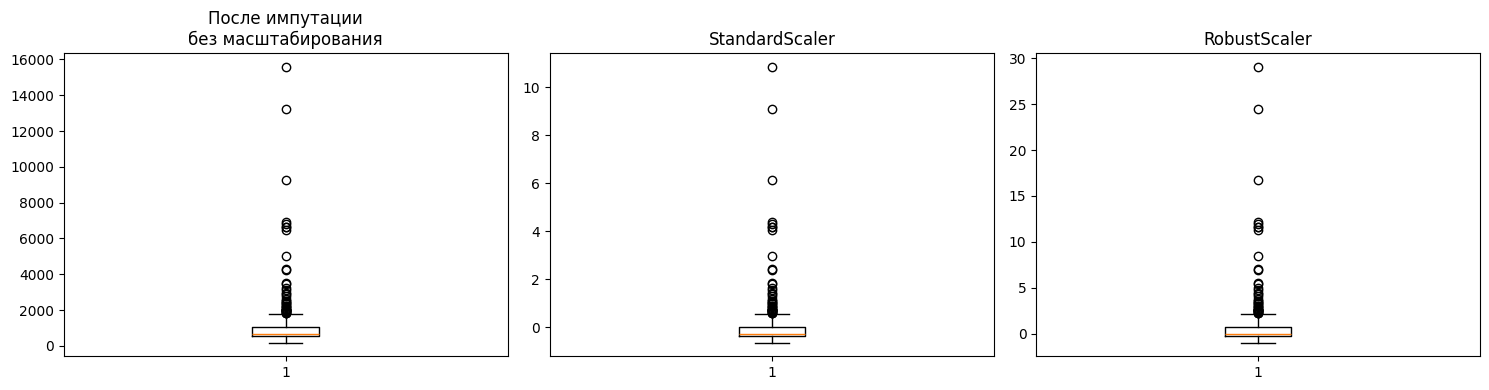

In [11]:

# Сравнение трансформации одного признака после StandardScaler и RobustScaler.
# Сначала заполняем пропуски, затем применяем оба скейлера к одному и тому же признаку.

feature_to_transform = "worst area"

# fit_transform только на train: скейлеры запоминают параметры (mean/std или median/IQR) с тренировочных данных
median_imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(
    median_imputer.fit_transform(X_train_corrupted),
    columns=X_train_corrupted.columns,
    index=X_train_corrupted.index,
)

standard_scaler = StandardScaler()  # (x - mean) / std — чувствителен к выбросам, т.к. mean и std зависят от них
robust_scaler = RobustScaler()      # (x - median) / IQR — устойчив к выбросам, т.к. использует квантили

x_std = standard_scaler.fit_transform(X_imp[[feature_to_transform]]).ravel()
x_rob = robust_scaler.fit_transform(X_imp[[feature_to_transform]]).ravel()
x_raw = X_imp[feature_to_transform].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ящики с усами позволяют сравнить масштаб и видимость выбросов после каждого трансформера
axes[0].boxplot(x_raw)
axes[0].set_title("После импутации\nбез масштабирования")

axes[1].boxplot(x_std)
axes[1].set_title("StandardScaler")

axes[2].boxplot(x_rob)
axes[2].set_title("RobustScaler")

plt.tight_layout()
plt.show()


## 7. Сохраняем артефакты лучшего эксперимента

Сохраним:

- таблицу метрик;
- JSON с параметрами постановки;
- лучшую fitted‑модель;
- небольшой комментарий по итогу эксперимента.

Это важный инженерный навык: эксперимент должен оставлять после себя не только вывод на экране, но и артефакты, к которым можно вернуться.


In [12]:

# Сохранение лучших результатов и метаданных.

# Берём первую строку из уже отфильтрованного corrupted_only (лучший эксперимент на загрязнённых данных)
best_row = corrupted_only.iloc[0].to_dict()
best_label = best_row["label"]
best_model = fitted_models[best_label]

# JSON-файл фиксирует все параметры эксперимента: позволяет воспроизвести или сравнить результаты позже
summary_payload = {
    "demo": "S07_demo_01_preprocessing_numeric_effect",
    "dataset": "sklearn breast_cancer",
    "random_state": RANDOM_STATE,
    "best_k_for_knn": int(best_k),
    "corrupted_setup": {
        "missing_fraction": 0.06,        # Доля ячеек, заменённых на NaN
        "outlier_fraction_rows": 0.03,   # Доля строк, в которых создавались выбросы
        "outlier_multiplier": 8.0,       # Во сколько раз значения умножаются для создания выброса
        "outlier_columns": outlier_columns,
    },
    "best_corrupted_experiment": {
        "label": best_label,
        "accuracy": float(best_row["accuracy"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
}

save_json(ARTIFACTS_DIR / "s07_demo_01_summary.json", summary_payload)     # Метаданные эксперимента
joblib.dump(best_model, ARTIFACTS_DIR / "s07_demo_01_best_model.joblib")   # Обученный пайплайн целиком

summary_payload


{'demo': 'S07_demo_01_preprocessing_numeric_effect',
 'dataset': 'sklearn breast_cancer',
 'random_state': 42,
 'best_k_for_knn': 11,
 'corrupted_setup': {'missing_fraction': 0.06,
  'outlier_fraction_rows': 0.03,
  'outlier_multiplier': 8.0,
  'outlier_columns': ['mean area', 'area error', 'worst area']},
 'best_corrupted_experiment': {'label': 'Mean_plus_Standard__kNN',
  'accuracy': 0.972027972027972,
  'f1': 0.978021978021978,
  'roc_auc': 0.9951781970649896}}

## 8. Итоги и ограничения

Из этого ноутбука нужно вынести несколько практических идей.

### Основные уроки

1. **Подготовка признаков может менять качество сильнее, чем кажется.**  
   Для kNN это особенно заметно, потому что модель напрямую зависит от расстояний между объектами.

2. **Импутация и масштабирование – часть модели, а не "предварительная магия".**  
   Их нужно включать в `Pipeline`, чтобы схема была воспроизводимой и корректной.

3. **Выбросы меняют геометрию пространства признаков.**  
   На "грязных" числовых данных `RobustScaler` может помочь, но это зависит от типа данных и величины выбросов.

4. **Потери качества могут идти от данных, а не только от алгоритма.**  
   Сравнение с `Reference_clean` показывает, сколько мы теряем из‑за ухудшения входных признаков.

### Ограничения этого эксперимента

- **Размер test‑набора мал** (~170 объектов), поэтому оценки метрик высокодисперсны. Различия в 0.1-0.2% могут быть случайными.
- **Один единственный train/test split** – результаты привязаны к этому конкретному разбиению. Для надёжных выводов нужна кросс‑валидация.
- **Уровень загрязнения выбран условно** (6% пропусков, 3% × 8 выбросов). На других данных эффект preprocessing может быть заметнее или менее заметен.
- **RobustScaler не показал преимущества** в этом эксперименте, но это не значит, что он бесполезен – всё зависит от характера данных.

### Как развивать дальше

- Добавить **cross-validation** для более стабильных оценок;
- Использовать **более тяжёлое загрязнение** (больше выбросов, больше пропусков) для более явного эффекта;
- Расширить на **смешанные признаки** через `ColumnTransformer`;
- Попробовать **другие модели** (не только kNN) и посмотреть, меняется ли влияние preprocessing.